In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures

In [5]:
def setup_plot(plt):
    plt.rcParams.update({
        'font.size': 10,
        'axes.labelweight': 'bold',
        'axes.edgecolor': '#333333',
    })
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_xlabel('x_1', labelpad=10)
    ax.set_ylabel('x_2', labelpad=10)
    ax.set_zlabel('y', labelpad=10)
    ax.view_init(elev=20, azim=-65)
    return ax, fig

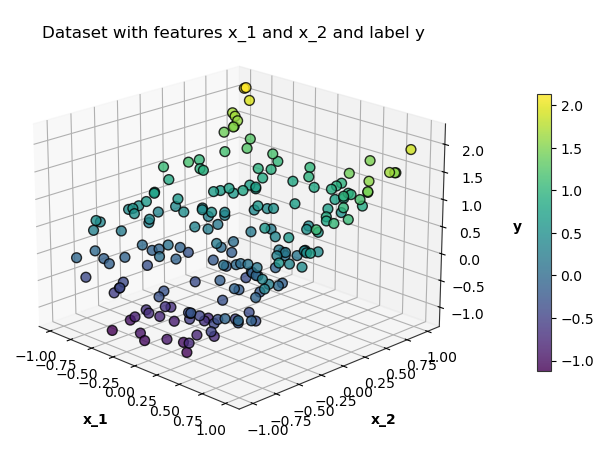

In [6]:
df = pd.read_csv('week3_data.csv', skiprows=1, names=['x1', 'x2', 'y'])

ax, fig = setup_plot(plt)
sc = ax.scatter(
    df['x1'],
    df['x2'],
    df['y'],
    c=df['y'].values,
    cmap='viridis',
    s=50,
    alpha=0.8,
    edgecolors='k',
    depthshade=True
)

ax.view_init(elev=20, azim=-45)
fig.colorbar(sc, ax=ax, pad=0.13, shrink=0.6)

plt.title('Dataset with features x_1 and x_2 and label y', y=1)
plt.show()

## Subsection B

In [7]:
pf = PolynomialFeatures(degree=5, include_bias=False)
X = pf.fit_transform(df[['x1', 'x2']])

c_values = [0.01, 1, 5, 10, 100, 1000]
models = []
for c in c_values:
    model = Ridge(alpha=1 / (2 * c), fit_intercept=True)
    model.fit(X, df[['y']].values)
    models.append(model)
    print(f'C: {c}, intercept: {model.intercept_}, coef: {model.coef_}')

C: 0.01, intercept: [0.22479469], coef: [-0.02006193  0.39639703  0.2120591  -0.00443943 -0.00636308  0.0092468
  0.11285164 -0.01392042  0.23225572  0.19295426 -0.00116632  0.08093584
 -0.02450391 -0.00221713  0.02353054  0.06330477 -0.0073184   0.06340168
 -0.01065148  0.16073993]
C: 1, intercept: [0.04616864], coef: [-0.03520883  0.80696044  0.68679716 -0.00259812 -0.00446727 -0.04632291
  0.20071587  0.00628376  0.18588488  0.24730876  0.20516337  0.02512161
 -0.20507053  0.05208349  0.14029846 -0.17733889 -0.11804131 -0.0635529
  0.06574818  0.04216058]
C: 5, intercept: [0.02264456], coef: [-0.01813598  0.8098199   0.8418732  -0.00241644 -0.01511374 -0.15734008
  0.42071641  0.02962447  0.12454355  0.10015675  0.26692632 -0.00453683
 -0.26292099  0.08451333  0.2742731  -0.42516823 -0.21135111 -0.07460754
  0.09074378  0.0909749 ]
C: 10, intercept: [0.01746212], coef: [-0.01027123  0.80554197  0.87984624 -0.00287116 -0.01985976 -0.20483551
  0.50983655  0.0415413   0.1007407   0.06

## Subsection C

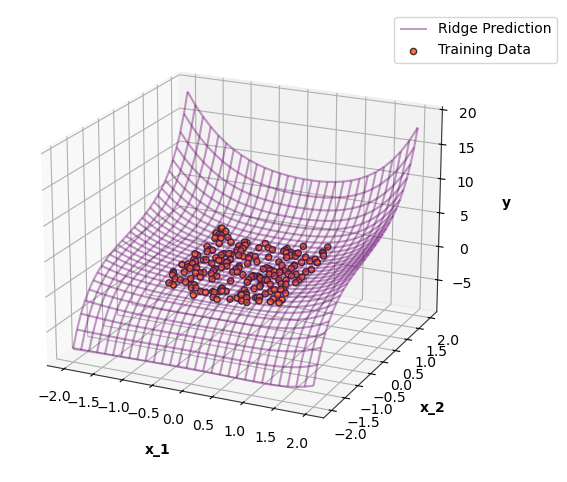

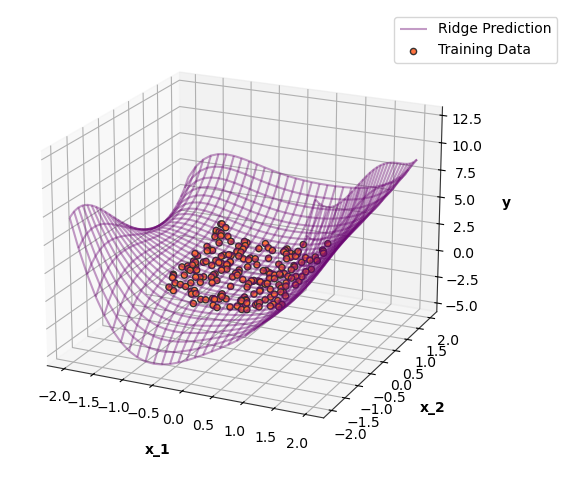

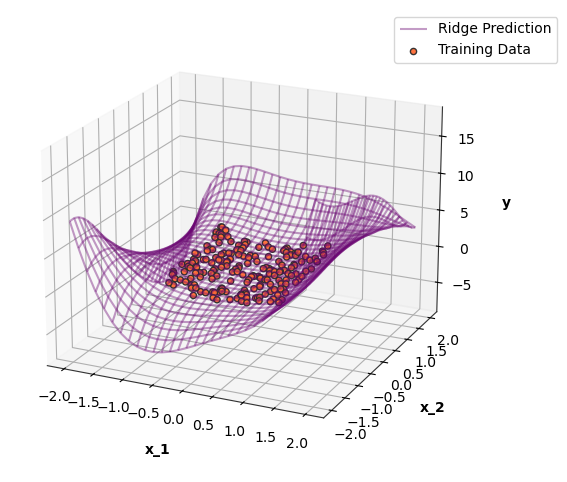

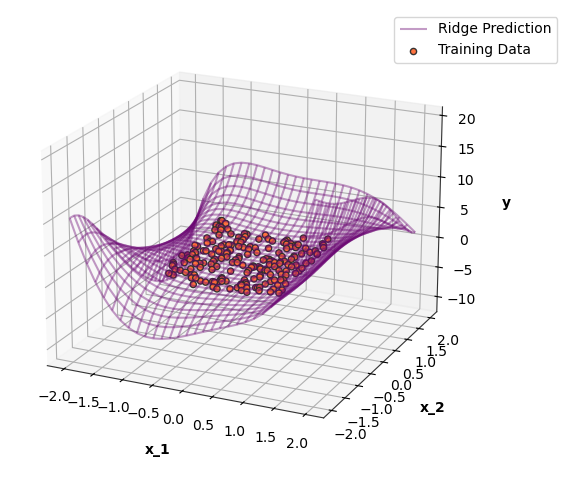

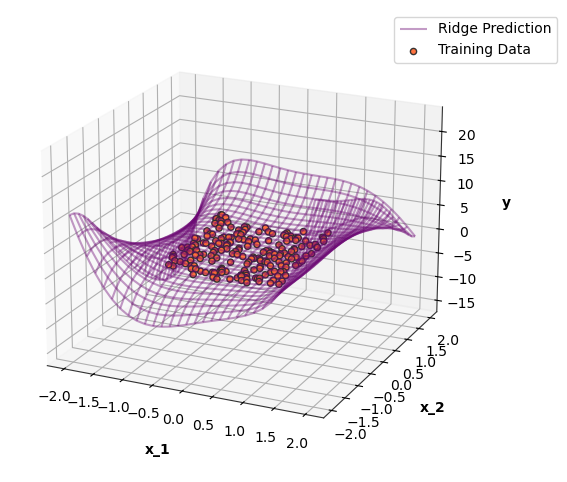

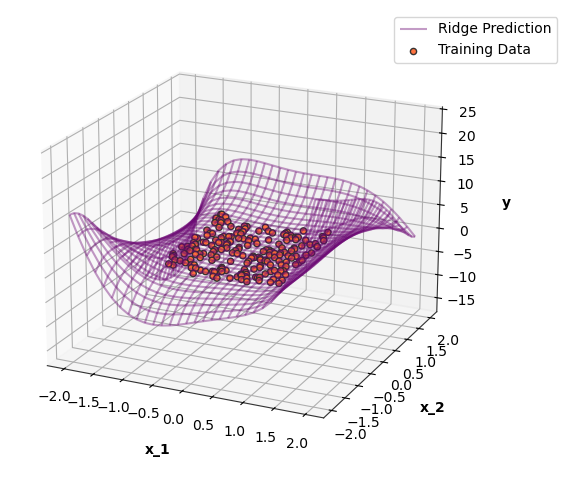

In [11]:
linear_space = np.linspace(-2,2, 30)
x1_grid, x2_grid = np.meshgrid(linear_space, linear_space)
test_grid = pf.fit_transform(np.column_stack((x1_grid.ravel(), x2_grid.ravel())))

for model in models:
    pred = model.predict(test_grid).reshape(x1_grid.shape)

    ax, _ = setup_plot(plt)
    ax.plot_wireframe(
        test_grid[:, 0].reshape(x1_grid.shape),
        test_grid[:, 1].reshape(x2_grid.shape),
        pred,
        color='#6A0572', alpha=0.4, label='Ridge Prediction'
    )
    ax.scatter(
        df['x1'], df['x2'], df['y'],
        c='#FF6B35', s=20, alpha=0.95, edgecolors='#2C2C2C', label='Training Data',
    )
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
    plt.show()